# Лабораторна робота 2_2. Харченко, ФІТ 3-10

Аналіз двох наборів даних з Kaggle:
1. **Titanic** - дані про пасажирів Титаніка
2. **Amazon Top 50 Bestselling Books 2009-2019** - 50 найпродаваніших книг Amazon за кожен рік

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

## Частина 1. Titanic

### 1. Завантаження даних
Датасет завантажуємо з Kaggle через бібліотеку kagglehub.

In [2]:
path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")
titanic = pd.read_csv(os.path.join(path, "titanic.csv"))
titanic.head()

100%|██████████| 22.0k/22.0k [00:00<00:00, 5.92MB/s]

Extracting files...


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Стовпці:
- Survived - вижив (1) чи ні (0)
- Pclass - клас квитка (1, 2, 3)
- Sex - стать, Age - вік
- SibSp - брати, сестри, чоловік або дружина на борту
- Parch - батьки або діти на борту
- Fare - ціна квитка, Cabin - каюта
- Embarked - порт посадки (S - Саутгемптон, C - Шербур, Q - Квінстаун)

### 2. Розмір і типи даних

In [3]:
print("Рядків:", titanic.shape[0])
print("Стовпців:", titanic.shape[1])
titanic.info()

Рядків: 891
Стовпців: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### 3. Дублікати

In [4]:
# перевіряємо до видалення стовпців, бо без імені різні люди можуть мати однакові дані
print("Дублікатів:", titanic.duplicated().sum())

Дублікатів: 0


### 4. Видалення зайвих стовпців

In [5]:
print("Пропусків у Cabin:", round(titanic["Cabin"].isna().mean() * 100, 1), "%")

# PassengerId, Name і Ticket в кожного свої, для аналізу нічого не дають
# Cabin пустий у більшості пасажирів, тому його теж видаляємо
titanic = titanic.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
titanic.head()

Пропусків у Cabin: 77.1 %


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### 5. Пропущені значення

In [6]:
titanic.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [7]:
# вік заповнюємо медіаною, вона менше залежить від дуже старих або дуже малих пасажирів
titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())

# порт посадки заповнюємо найчастішим значенням
titanic["Embarked"] = titanic["Embarked"].fillna(titanic["Embarked"].mode()[0])

titanic.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


### 6. Описова статистика

In [8]:
titanic.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 7. Скільки пасажирів вижило

In [9]:
print(titanic["Survived"].value_counts())
print("Вижило:", round(titanic["Survived"].mean() * 100, 1), "%")

Survived
0    549
1    342
Name: count, dtype: int64
Вижило: 38.4 %


### 8. Виживання за статтю

Sex
female    74.2
male      18.9
Name: Survived, dtype: float64


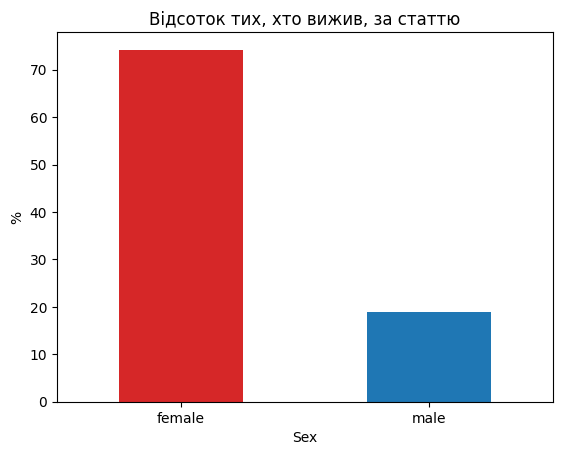

In [10]:
by_sex = titanic.groupby("Sex")["Survived"].mean() * 100
print(by_sex.round(1))

by_sex.plot(kind="bar", color=["tab:red", "tab:blue"])
plt.title("Відсоток тих, хто вижив, за статтю")
plt.ylabel("%")
plt.xticks(rotation=0)
plt.show()

### 9. Виживання за класом

Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64


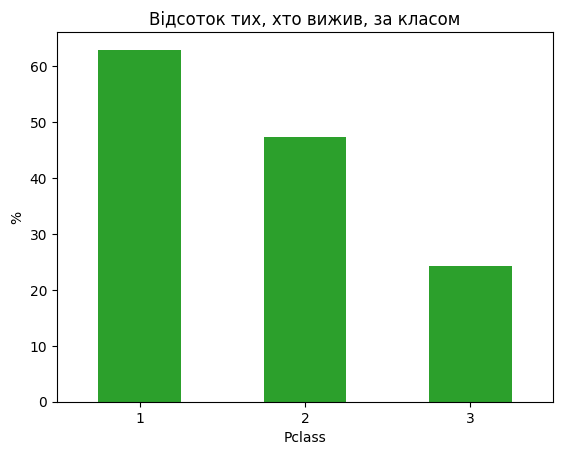

In [11]:
by_class = titanic.groupby("Pclass")["Survived"].mean() * 100
print(by_class.round(1))

by_class.plot(kind="bar", color="tab:green")
plt.title("Відсоток тих, хто вижив, за класом")
plt.ylabel("%")
plt.xticks(rotation=0)
plt.show()

### 10. Стать і клас разом

In [12]:
pd.pivot_table(titanic, values="Survived", index="Sex", columns="Pclass", aggfunc="mean").mul(100).round(1)

Pclass,1,2,3
Sex,,,
female,96.8,92.1,50.0
male,36.9,15.7,13.5


### 11. Вік

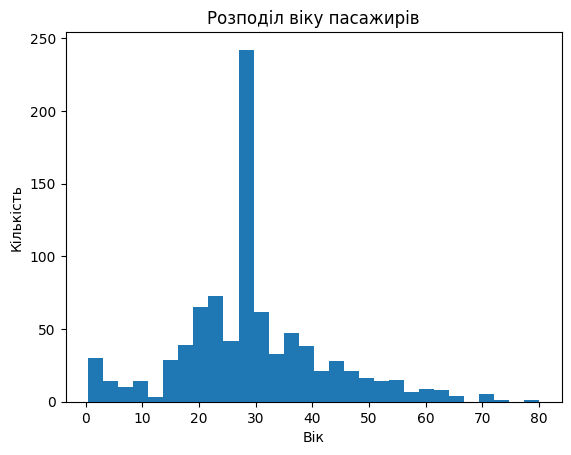

In [13]:
plt.hist(titanic["Age"], bins=30)
plt.title("Розподіл віку пасажирів")
plt.xlabel("Вік")
plt.ylabel("Кількість")
plt.show()
# пік біля 28 років - це пропуски, які ми заповнили медіаною

In [14]:
titanic["AgeGroup"] = pd.cut(titanic["Age"], bins=[0, 12, 18, 40, 60, 80],
                             labels=["0-12", "13-18", "19-40", "41-60", "61-80"])
age_table = titanic.groupby("AgeGroup", observed=True)["Survived"].agg(["count", "mean"])
age_table["mean"] = (age_table["mean"] * 100).round(1)
age_table.columns = ["Пасажирів", "Вижило, %"]
age_table

,Пасажирів,"Вижило, %"
AgeGroup,,
0-12,69,58.0
13-18,70,42.9
19-40,602,36.0
41-60,128,39.1
61-80,22,22.7


### 12. Ціна квитка

In [15]:
print("Середня і медіанна ціна квитка за класом:")
print(titanic.groupby("Pclass")["Fare"].agg(["mean", "median"]).round(2))
print()
print("Середня ціна квитка (0 - загинули, 1 - вижили):")
print(titanic.groupby("Survived")["Fare"].mean().round(2))

Середня і медіанна ціна квитка за класом:
         mean  median
Pclass               
1       84.15   60.29
2       20.66   14.25
3       13.68    8.05

Середня ціна квитка (0 - загинули, 1 - вижили):
Survived
0    22.12
1    48.40
Name: Fare, dtype: float64


### 13. Розмір сім'ї

        Пасажирів  Вижило, %
Family                      
1             537       30.4
2             161       55.3
3             102       57.8
4              29       72.4
5              15       20.0
6              22       13.6
7              12       33.3
8               6        0.0
11              7        0.0


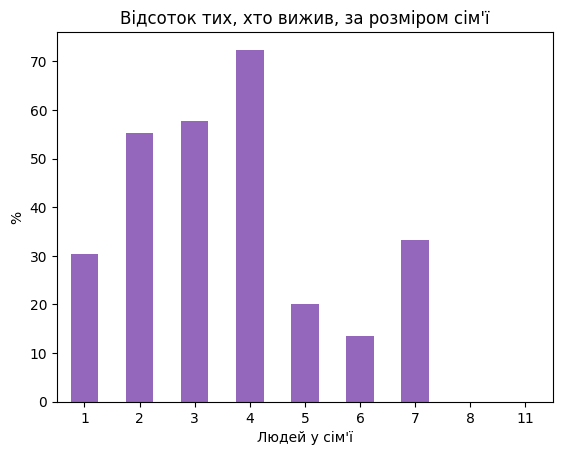

In [16]:
# сім'я = брати/сестри/подружжя + батьки/діти + сама людина
titanic["Family"] = titanic["SibSp"] + titanic["Parch"] + 1

family = titanic.groupby("Family")["Survived"].agg(["count", "mean"])
family["mean"] = (family["mean"] * 100).round(1)
family.columns = ["Пасажирів", "Вижило, %"]
print(family)

family["Вижило, %"].plot(kind="bar", color="tab:purple")
plt.title("Відсоток тих, хто вижив, за розміром сім'ї")
plt.xlabel("Людей у сім'ї")
plt.ylabel("%")
plt.xticks(rotation=0)
plt.show()

### 14. Порт посадки

In [17]:
titanic.groupby("Embarked")["Survived"].agg(["count", "mean"]).round(3)

,count,mean
Embarked,,
C,168,0.554
Q,77,0.390
S,646,0.339


### 15. Кореляція

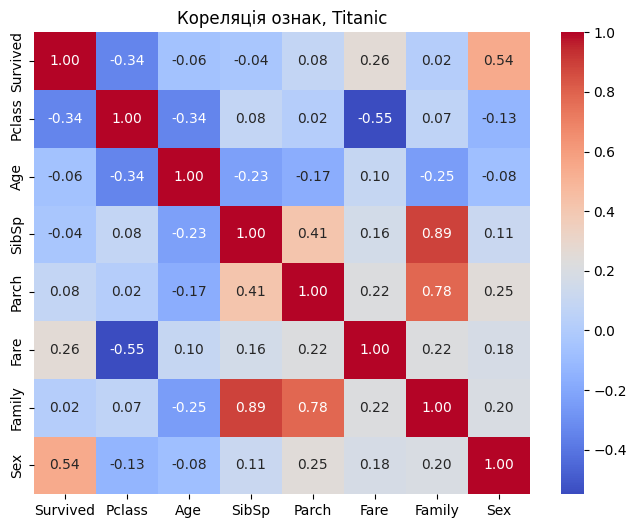

Кореляція з Survived:
Sex       0.54
Fare      0.26
Parch     0.08
Family    0.02
SibSp    -0.04
Age      -0.06
Pclass   -0.34
Name: Survived, dtype: float64


In [18]:
num = titanic[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "Family"]].copy()
num["Sex"] = (titanic["Sex"] == "female").astype(int)  # 1 - жінка, 0 - чоловік

corr = num.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Кореляція ознак, Titanic")
plt.show()

print("Кореляція з Survived:")
print(corr["Survived"].drop("Survived").sort_values(ascending=False).round(2))

### Висновки по Titanic
- вижило тільки 38,4% пасажирів (342 з 891)
- найсильніше на виживання впливала стать: вижило 74% жінок і тільки 19% чоловіків (кореляція 0.54)
- також дуже важливий клас: у 1 класі вижило 63%, у 3 класі тільки 24%. Жінки з 1 і 2 класу вижили майже всі (97% і 92%)
- діти до 12 років виживали частіше за інших (58%), а пасажири старші 60 найрідше (23%)
- ті, хто вижив, в середньому платили за квиток більше (48 проти 22), це пов'язано з класом
- найкраще виживали сім'ї з 2-4 людей, а пасажири без сім'ї і великі сім'ї (5 і більше людей) виживали гірше
- пасажири, які сіли в Шербурі (C), вижили частіше (55%), мабуть тому, що серед них було багато пасажирів 1 класу

## Частина 2. Amazon Top 50 Bestselling Books 2009-2019

### 1. Завантаження даних

In [19]:
path = kagglehub.dataset_download("sootersaalu/amazon-top-50-bestselling-books-2009-2019")
books = pd.read_csv(os.path.join(path, "bestsellers with categories.csv"))
books.head()

100%|██████████| 14.5k/14.5k [00:00<00:00, 12.8MB/s]

Extracting files...


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


Стовпці: Name - назва книги, Author - автор, User Rating - рейтинг (до 5), Reviews - кількість відгуків, Price - ціна в доларах, Year - рік, Genre - жанр (Fiction - художня, Non Fiction - нехудожня).

### 2. Розмір і типи даних

In [20]:
print("Рядків:", books.shape[0])
print("Стовпців:", books.shape[1])
books.info()

Рядків: 550
Стовпців: 7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    object 
 1   Author       550 non-null    object 
 2   User Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Price        550 non-null    int64  
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 30.2+ KB


### 3. Пропуски і дублікати

In [21]:
print("Пропусків:")
print(books.isna().sum())
print()
print("Повних дублікатів:", books.duplicated().sum())
print("Унікальних книг:", books["Name"].nunique(), "з", len(books))
# одна книга може бути в топі кілька років підряд, це не дублікат, тому нічого не видаляємо

Пропусків:
Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64

Повних дублікатів: 0
Унікальних книг: 351 з 550


### 4. Очистка даних

In [22]:
# один і той самий автор записаний по-різному
print(books.loc[books["Author"].str.contains("Martin|Rowling"), "Author"].unique())

books["Author"] = books["Author"].replace({"George R. R. Martin": "George R.R. Martin",
                                           "J. K. Rowling": "J.K. Rowling"})
print(books.loc[books["Author"].str.contains("Martin|Rowling"), "Author"].unique())

['George R. R. Martin' 'Bill Martin Jr.' 'J.K. Rowling'
 'George R.R. Martin' 'J. K. Rowling' 'Emily Winfield Martin']
['George R.R. Martin' 'Bill Martin Jr.' 'J.K. Rowling'
 'Emily Winfield Martin']


In [23]:
# книги з ціною 0
print("Книг з ціною 0:", (books["Price"] == 0).sum())
books[books["Price"] == 0][["Name", "Author", "Year"]]

Книг з ціною 0: 12


,Name,Author,Year
42,"Cabin Fever (Diary of a Wimpy Kid, Book 6)",Jeff Kinney,2011
71,"Diary of a Wimpy Kid: Hard Luck, Book 8",Jeff Kinney,2013
116,Frozen (Little Golden Book),RH Disney,2014
193,JOURNEY TO THE ICE P,RH Disney,2014
219,Little Blue Truck,Alice Schertle,2014
358,The Constitution of the United States,Delegates of the Constitutional,2016
381,The Getaway,Jeff Kinney,2017
461,The Short Second Life of Bree Tanner: An Eclip...,Stephenie Meyer,2010
505,To Kill a Mockingbird,Harper Lee,2013
506,To Kill a Mockingbird,Harper Lee,2014


### 5. Описова статистика

In [24]:
books.describe()

,User Rating,Reviews,Price,Year
count,550.000000,550.000000,550.000000,550.000000
mean,4.618364,11953.281818,13.100000,2014.000000
std,0.226980,11731.132017,10.842262,3.165156
min,3.300000,37.000000,0.000000,2009.000000
25%,4.500000,4058.000000,7.000000,2011.000000
50%,4.700000,8580.000000,11.000000,2014.000000
75%,4.800000,17253.250000,16.000000,2017.000000
max,4.900000,87841.000000,105.000000,2019.000000


### 6. Жанри

Genre
Non Fiction    310
Fiction        240
Name: count, dtype: int64


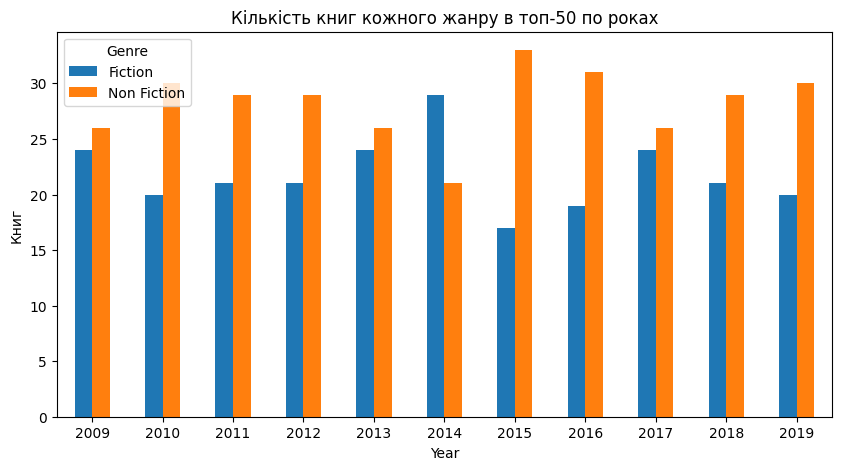

In [25]:
print(books["Genre"].value_counts())

genre_year = pd.crosstab(books["Year"], books["Genre"])
genre_year.plot(kind="bar", figsize=(10, 5))
plt.title("Кількість книг кожного жанру в топ-50 по роках")
plt.ylabel("Книг")
plt.xticks(rotation=0)
plt.show()

### 7. Ціна

Ціна за жанром:
              mean  median  max
Genre                          
Fiction      10.85     9.0   82
Non Fiction  14.84    12.0  105


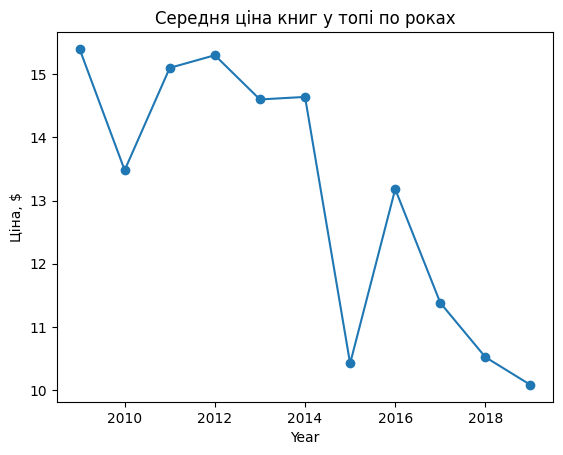

In [26]:
print("Ціна за жанром:")
print(books.groupby("Genre")["Price"].agg(["mean", "median", "max"]).round(2))

books.groupby("Year")["Price"].mean().plot(marker="o")
plt.title("Середня ціна книг у топі по роках")
plt.ylabel("Ціна, $")
plt.show()

In [27]:
# найдорожчі книги (кожну книгу беремо один раз)
books.drop_duplicates("Name").nlargest(5, "Price")[["Name", "Author", "Price", "Genre"]]

,Name,Author,Price,Genre
69,Diagnostic and Statistical Manual of Mental Di...,American Psychiatric Association,105,Non Fiction
473,The Twilight Saga Collection,Stephenie Meyer,82,Fiction
151,Hamilton: The Revolution,Lin-Manuel Miranda,54,Non Fiction
346,The Book of Basketball: The NBA According to T...,Bill Simmons,53,Non Fiction
159,Harry Potter Paperback Box Set (Books 1-7),J.K. Rowling,52,Fiction


### 8. Рейтинг

Середній рейтинг за жанром:
Genre
Fiction        4.648
Non Fiction    4.595
Name: User Rating, dtype: float64


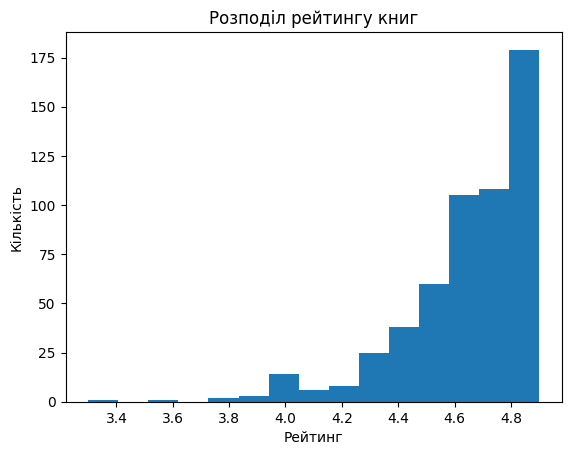

In [28]:
print("Середній рейтинг за жанром:")
print(books.groupby("Genre")["User Rating"].mean().round(3))

plt.hist(books["User Rating"], bins=15)
plt.title("Розподіл рейтингу книг")
plt.xlabel("Рейтинг")
plt.ylabel("Кількість")
plt.show()

In [29]:
# книги з найнижчим рейтингом
books.drop_duplicates("Name").nsmallest(5, "User Rating")[["Name", "Author", "User Rating", "Year"]]

,Name,Author,User Rating,Year
353,The Casual Vacancy,J.K. Rowling,3.3,2012
132,Go Set a Watchman: A Novel,Harper Lee,3.6,2015
106,Fifty Shades of Grey: Book One of the Fifty Sh...,E L James,3.8,2012
22,Allegiant,Veronica Roth,3.9,2013
392,The Goldfinch: A Novel (Pulitzer Prize for Fic...,Donna Tartt,3.9,2013


### 9. Автори

Author
Jeff Kinney                           12
Suzanne Collins                       11
Gary Chapman                          11
Rick Riordan                          11
American Psychological Association    10
Dr. Seuss                              9
Gallup                                 9
Rob Elliott                            8
J.K. Rowling                           8
Stephen R. Covey                       7
Name: count, dtype: int64


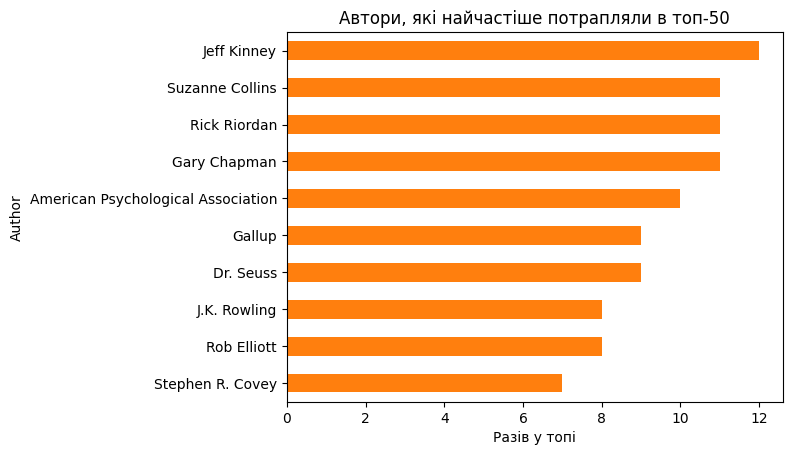

In [30]:
top_authors = books["Author"].value_counts().head(10)
print(top_authors)

top_authors.sort_values().plot(kind="barh", color="tab:orange")
plt.title("Автори, які найчастіше потрапляли в топ-50")
plt.xlabel("Разів у топі")
plt.show()

### 10. Книги з найбільшою кількістю відгуків

In [31]:
books.drop_duplicates("Name").nlargest(10, "Reviews")[["Name", "Author", "Reviews", "Genre"]]

,Name,Author,Reviews,Genre
534,Where the Crawdads Sing,Delia Owens,87841,Fiction
382,The Girl on the Train,Paula Hawkins,79446,Fiction
32,Becoming,Michelle Obama,61133,Non Fiction
135,Gone Girl,Gillian Flynn,57271,Fiction
365,The Fault in Our Stars,John Green,50482,Fiction
437,The Nightingale: A Novel,Kristin Hannah,49288,Fiction
106,Fifty Shades of Grey: Book One of the Fifty Sh...,E L James,47265,Fiction
433,The Martian,Andy Weir,39459,Fiction
20,All the Light We Cannot See,Anthony Doerr,36348,Fiction
338,The Alchemist,Paulo Coelho,35799,Fiction


### 11. Кореляція

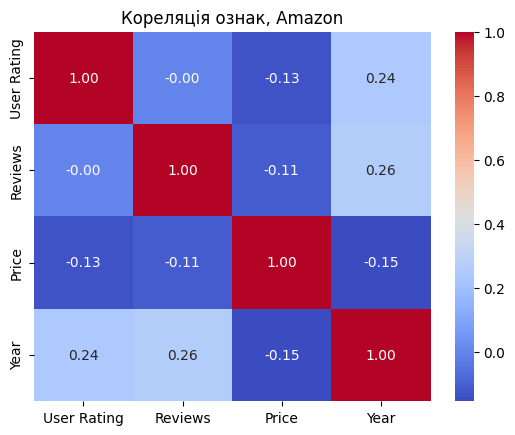

In [32]:
corr_books = books[["User Rating", "Reviews", "Price", "Year"]].corr()
sns.heatmap(corr_books, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Кореляція ознак, Amazon")
plt.show()

### Висновки по Amazon
- у таблиці 550 записів, але тільки 351 унікальна книга, бо багато книг були в топі кілька років
- нехудожніх книг (Non Fiction) у топі більше: 310 проти 240. Тільки у 2014 художніх було більше (29 з 50)
- нехудожні книги в середньому дорожчі (14,8$ проти 10,9$), найдорожча книга - DSM-5 за 105$. Є 12 записів з ціною 0
- середня ціна книг у топі з роками падає (з 15,4$ у 2009 до 10,1$ у 2019), а середній рейтинг навпаки росте (з 4,58 до 4,74)
- рейтинги загалом дуже високі (в середньому 4,6), найнижчий у The Casual Vacancy від J.K. Rowling (3,3)
- найчастіше в топ потрапляв Jeff Kinney (Diary of a Wimpy Kid), 12 разів
- найбільше відгуків у книги Where the Crawdads Sing, майже 88 тисяч
- сильних кореляцій між рейтингом, кількістю відгуків і ціною немає (всі коефіцієнти менше 0,3 за модулем), тобто дорожча книга не означає вищий рейтинг